In [1]:
import os
import numpy as np
import d3rlpy
import csv
import matplotlib.pyplot as plt

def read_Episodes(baseFolder):
    episodes = []
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            next(reader)  # Skip header row
            for row in reader:
                observation = [float(epi) for epi in row]
                episode.append(observation)
            episodes.append(episode)
    return episodes

def load_models_from_training(training_dir):
    models = []
    model_files = sorted([f for f in os.listdir(training_dir) if f.endswith('.d3')])
    
    if len(model_files) > 10:
        step = (len(model_files) - 1) / 9
        selected_indices = [int(i * step) for i in range(9)]
        selected_indices.append(len(model_files) - 1)
        selected_indices = sorted(list(set(selected_indices)))
        model_files = [model_files[i] for i in selected_indices]
    for i,model_file in enumerate(model_files):
        model_path = os.path.join(training_dir, model_file)
        try:
            model = d3rlpy.load_learnable(model_path)
            models.append(((str(i)+model_file), model)) 
        except Exception as e:
            print(f"Error loading {model_file}: {e}")
    return models

def load_latest_model_from_folder(model_folders, include_subfolders=False):
    """
    Lädt nur das neueste Modell aus einem oder mehreren Ordnern.
    
    Args:
        model_folders (str or list): Pfad zum Ordner oder Liste von Pfaden mit Modellen (.d3 Dateien)
        include_subfolders (bool): Ob Unterordner durchsucht werden sollen
    
    Returns:
        list: Liste von Tupeln (model_name_with_folder, model_object) - nur die neuesten Modelle
    """
    models = []
    
    # Normalisiere input zu Liste
    if isinstance(model_folders, str):
        model_folders = [model_folders]
    
    for folder_path in model_folders:
        if not os.path.exists(folder_path):
            print(f"⚠️  Ordner existiert nicht: {folder_path}")
            continue
            
        folder_name = os.path.basename(folder_path)
        print(f"\n📁 Durchsuche Ordner: {folder_name} ({folder_path})")
        
        if include_subfolders:
            # Rekursive Suche: Für jeden Unterordner das neueste Modell finden
            subfolders_processed = set()
            
            for root, dirs, files in os.walk(folder_path):
                d3_files = [f for f in files if f.endswith('.d3')]
                if not d3_files:
                    continue
                
                # Sortiere nach Dateinamen (neuestes = alphabetisch letztes)
                d3_files.sort()
                latest_file = d3_files[-1]
                
                relative_root = os.path.relpath(root, folder_path)
                if relative_root == '.':
                    # Hauptordner
                    subfolder_key = 'main'
                    model_name = f"{folder_name}_{latest_file}"
                else:
                    # Unterordner
                    subfolder_key = relative_root
                    subfolder_clean = relative_root.replace(os.sep, '_')
                    model_name = f"{folder_name}_{subfolder_clean}_{latest_file}"
                
                if subfolder_key in subfolders_processed:
                    continue
                subfolders_processed.add(subfolder_key)
                
                model_path = os.path.join(root, latest_file)
                try:
                    model = d3rlpy.load_learnable(model_path)
                    models.append((model_name, model))
                    print(f"   ✓ Neuestes Modell geladen: {model_name}")
                except Exception as e:
                    print(f"   ✗ Fehler beim Laden von {latest_file}: {e}")
        
        else:
            # Nur Hauptordner: Das neueste Modell finden
            model_files = [f for f in os.listdir(folder_path) if f.endswith('.d3')]
            
            if not model_files:
                print(f"   ⚠️  Keine .d3 Dateien gefunden")
                continue
            
            # Sortiere nach Dateinamen (neuestes = alphabetisch letztes)
            model_files.sort()
            latest_model_file = model_files[-1]
            
            print(f"   Verfügbare Modelle: {len(model_files)}, wähle neuestes: {latest_model_file}")
            
            model_path = os.path.join(folder_path, latest_model_file)
            try:
                model = d3rlpy.load_learnable(model_path)
                model_name = f"{folder_name}_{latest_model_file}"
                models.append((model_name, model))
                print(f"   ✓ Neuestes Modell geladen: {model_name}")
            except Exception as e:
                print(f"   ✗ Fehler beim Laden von {latest_model_file}: {e}")
    
    print(f"\n🎯 Gesamt: {len(models)} neueste Modelle erfolgreich geladen aus {len(model_folders)} Ordnern")
    return models

def load_all_models_from_folder(model_folders, include_subfolders=False):
    """
    Lädt alle Modelle aus einem oder mehreren Ordnern.
    
    Args:
        model_folders (str or list): Pfad zum Ordner oder Liste von Pfaden mit Modellen (.d3 Dateien)
        include_subfolders (bool): Ob Unterordner durchsucht werden sollen
    
    Returns:
        list: Liste von Tupeln (model_name_with_folder, model_object)
    """
    models = []
    
    # Normalisiere input zu Liste
    if isinstance(model_folders, str):
        model_folders = [model_folders]
    
    total_models_found = 0
    
    for folder_path in model_folders:
        if not os.path.exists(folder_path):
            print(f"⚠️  Ordner existiert nicht: {folder_path}")
            continue
            
        folder_name = os.path.basename(folder_path)
        print(f"\n📁 Durchsuche Ordner: {folder_name} ({folder_path})")
        
        # Sammle alle .d3 Dateien
        model_files = []
        if include_subfolders:
            # Rekursive Suche durch alle Unterordner
            for root, dirs, files in os.walk(folder_path):
                relative_paths = []
                for file in files:
                    if file.endswith('.d3'):
                        relative_path = os.path.relpath(os.path.join(root, file), folder_path)
                        relative_paths.append(relative_path) 
                if len(relative_paths) > 0:
                    model_files.append(relative_paths[-1]) 
        else:
            # Nur direkte Dateien im Ordner
            model_files = [f for f in os.listdir(folder_path) if f.endswith('.d3')]
        
        model_files = sorted(model_files)
        print(f"   Gefundene Modelle: {len(model_files)}")
        total_models_found += len(model_files)
        
        for model_file in model_files:
            model_path = os.path.join(folder_path, model_file)
            try:
                model = d3rlpy.load_learnable(model_path)
                
                # Erstelle aussagekräftigen Namen
                if include_subfolders and os.path.dirname(model_file):
                    # Bei Unterordnern: Folder_Subfolder_Modelname
                    subfolder = os.path.dirname(model_file).replace(os.sep, '_')
                    model_name = f"{folder_name}_{subfolder}_{os.path.basename(model_file)}"
                else:
                    # Bei direkten Dateien: Folder_Modelname
                    model_name = f"{folder_name}_{model_file}"
                
                models.append((model_name, model))
                print(f"   ✓ Modell geladen: {model_name}")
                
            except Exception as e:
                print(f"   ✗ Fehler beim Laden von {model_file}: {e}")
    
    print(f"\n🎯 Gesamt: {len(models)} von {total_models_found} Modellen erfolgreich geladen aus {len(model_folders)} Ordnern")
    return models

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



📁 Durchsuche Ordner: test logs (logs/test logs)
   Gefundene Modelle: 4


c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

   ✓ Modell geladen: test logs_BCQ_20260123232713_model_95000.d3
   ✓ Modell geladen: test logs_CQL_20260124015439_model_95000.d3
   ✓ Modell geladen: test logs_IQL_20260124043738_model_95000.d3
   ✓ Modell geladen: test logs_PLAS_20260124060503_model_95000.d3

🎯 Gesamt: 4 von 4 Modellen erfolgreich geladen aus 1 Ordnern
Plotte die ersten 5 von 5 verfügbaren Episoden

Plotte Tag 1 von 5...


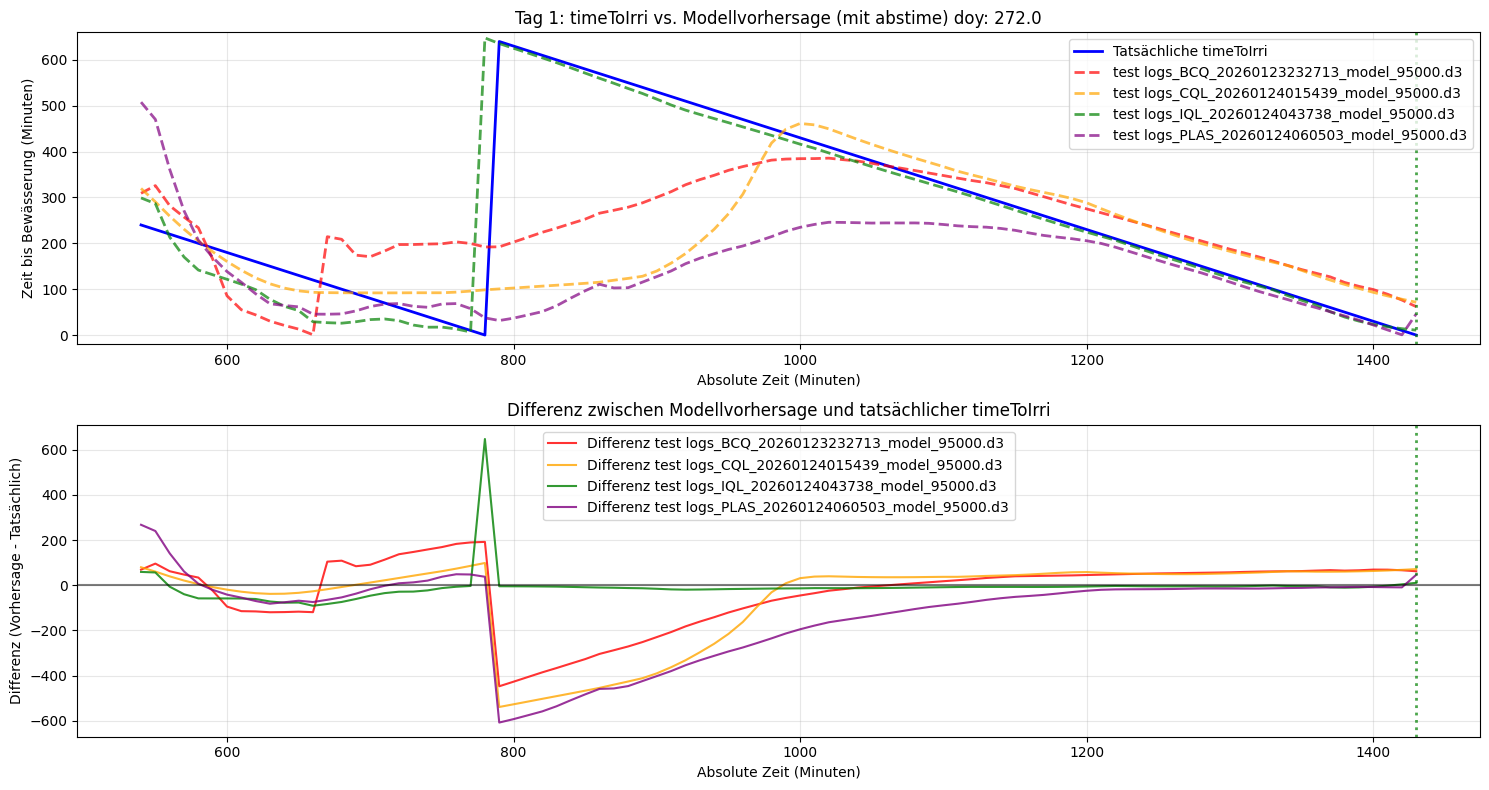


Plotte Tag 2 von 5...


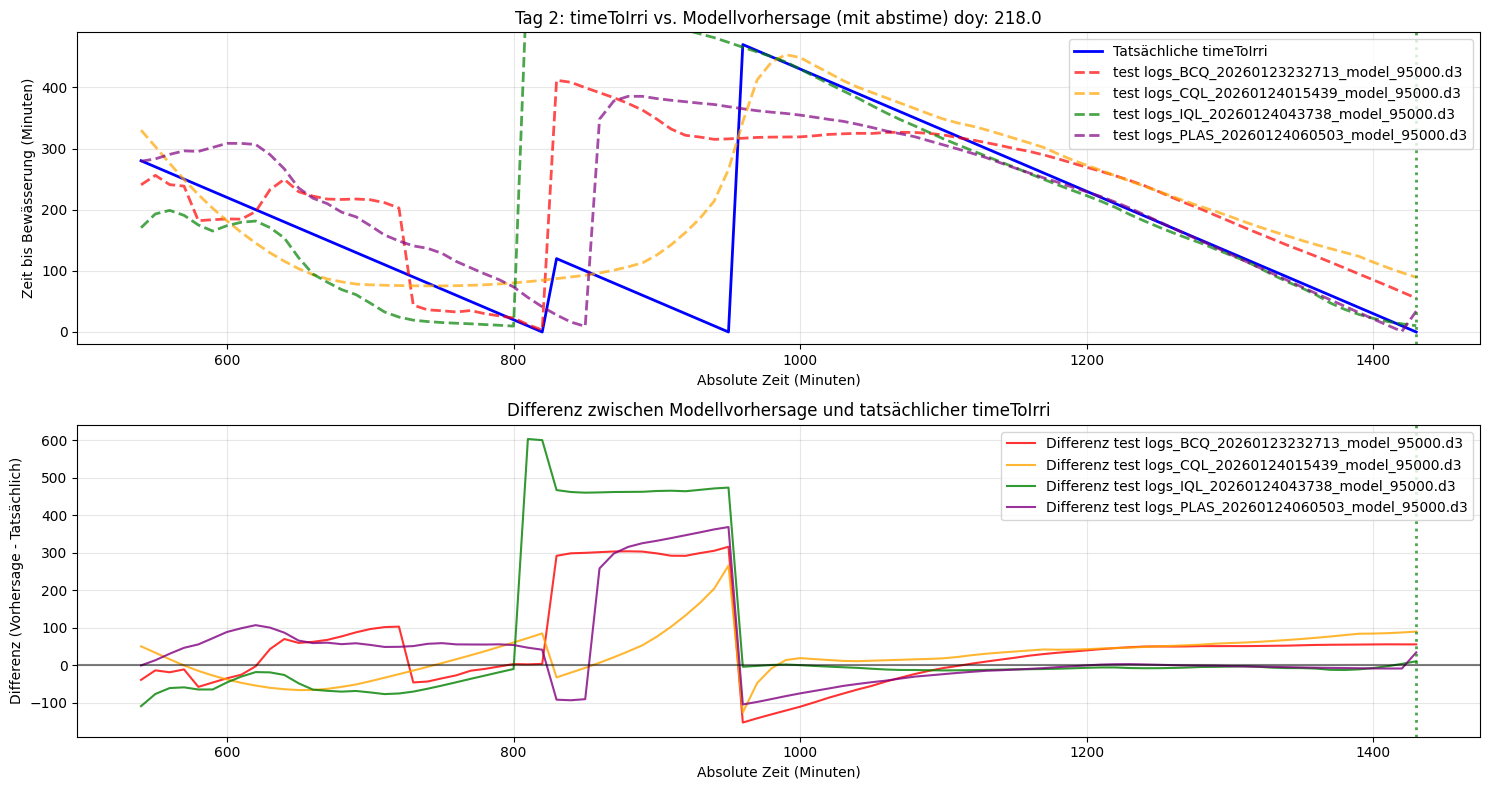


Plotte Tag 3 von 5...


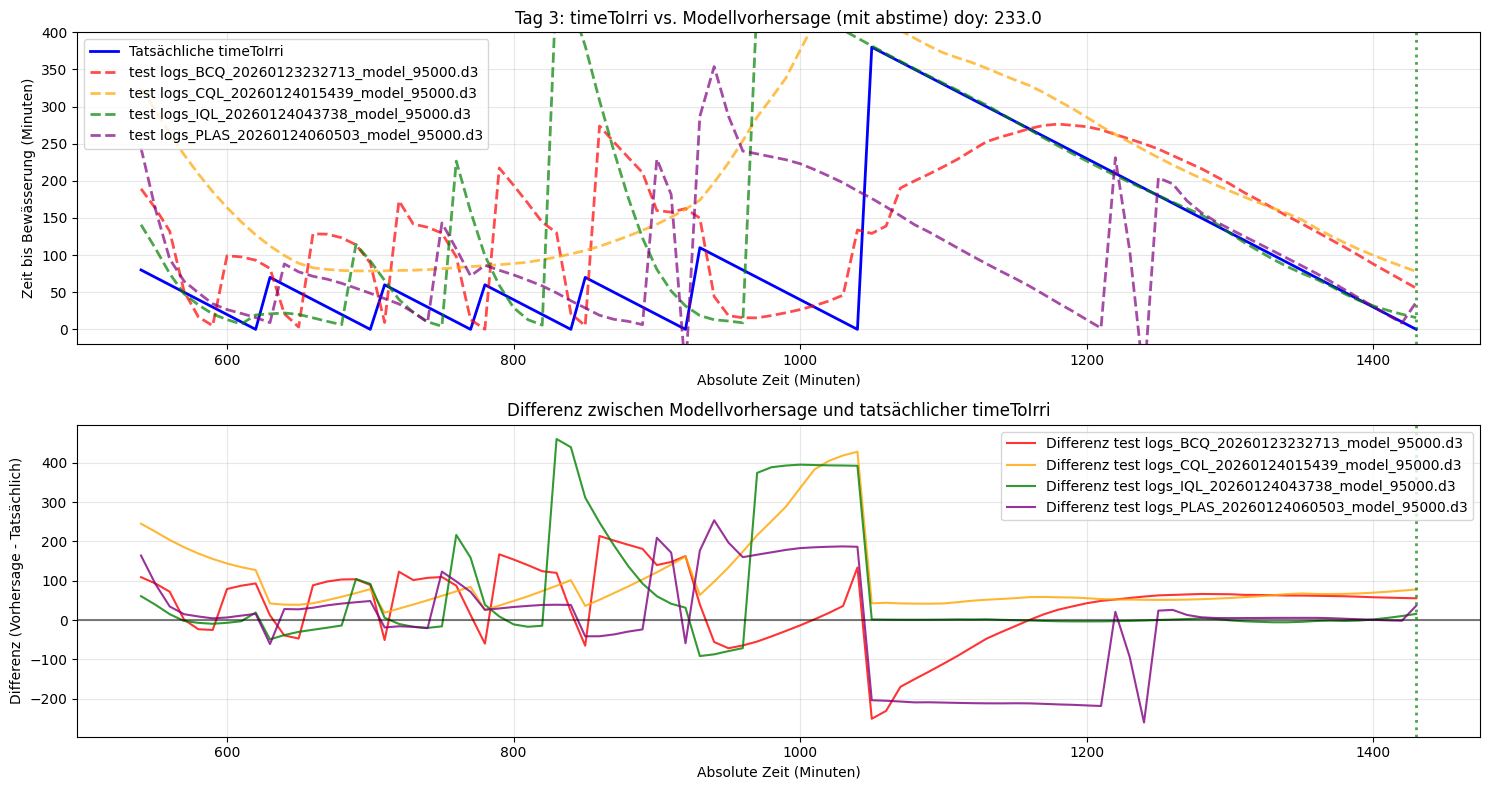


Plotte Tag 4 von 5...


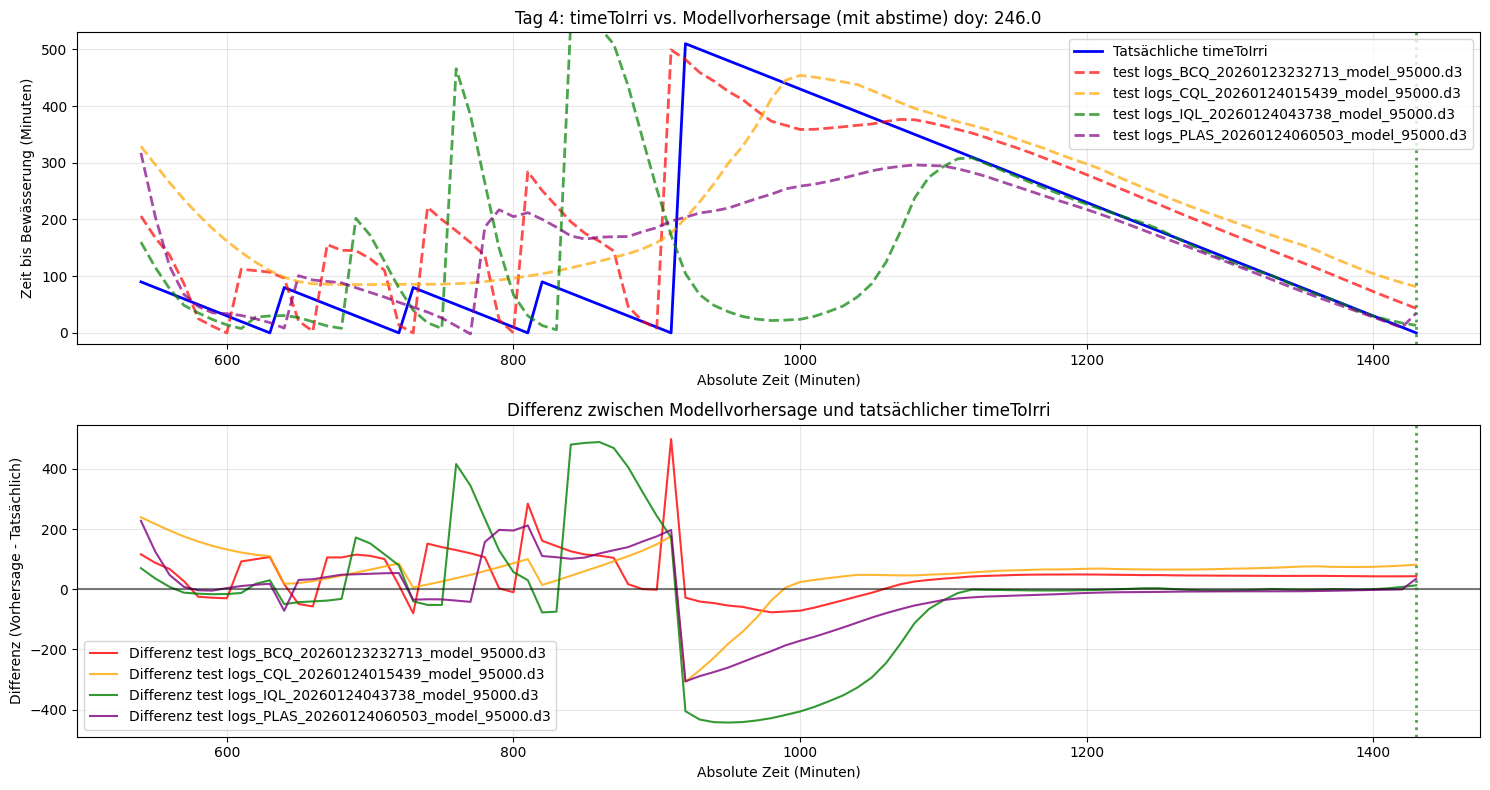


Plotte Tag 5 von 5...


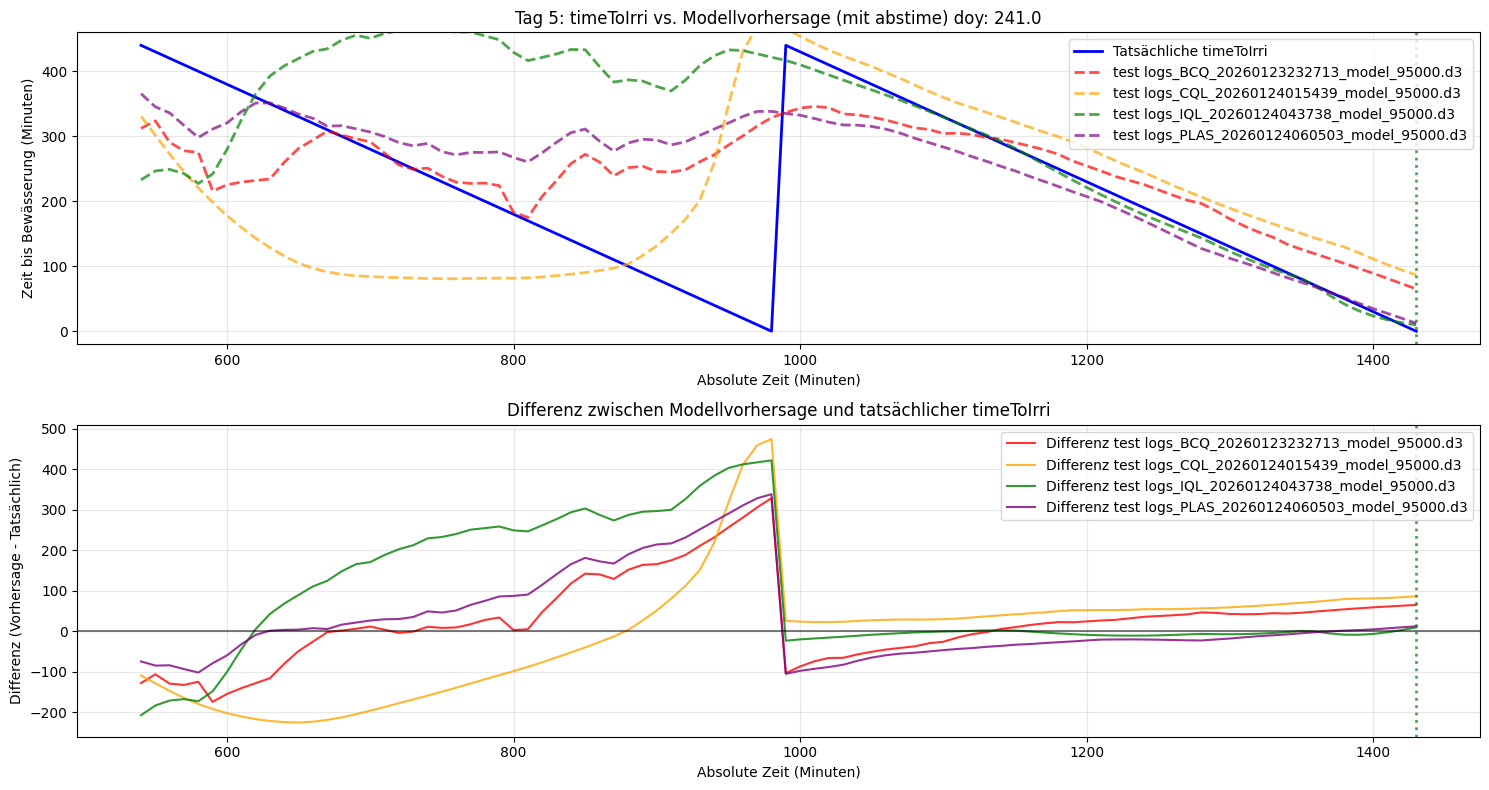

In [2]:
def plot_single_day_progression(episode, episode_index, models, model_names):
    """
    Plottet den Tagesverlauf einer einzelnen Episode.
    
    Args:
        episode (list): Episode Daten
        episode_index (int): Index der Episode
        model: Das geladene Modell
        model_name (str): Name des Modells
    """
    
    # Extrahiere Daten aus der Episode
    abstimes = [sample[1] for sample in episode]  # abstime column (absolute time in minutes)
    time_to_irri_actual = [sample[10] for sample in episode]  # timeToIrri column
    terminals = [sample[9] for sample in episode]  # terminal column
    
    # Generiere Vorhersagen
    MultiPredictions = []
    
    for model in models:
        predictions = []
        lastIrrigationTime = 0
        irriAmount = episode[0][11] -5 # initial drain amount -5 to account for first irrigation (ignore first irrigation)
        pred = 0.0
        for sample in episode:
            obs = np.array([sample[:-5]])  # Alle Features außer den letzten 5 (konsistent mit anderen Funktionen)
            try:
                if pred <= 10.0:
                    lastIrrigationTime = 0  # Reset bei Bewässerung
                    obs[0][6] = 0 # Drain
                    irriAmount += 5
                    drain = sample[11] - irriAmount
                    if drain < 0: # Drain nie negativ
                        drain = 0
                if lastIrrigationTime == 10:
                    obs[0][6] = drain * 0.7 # 70% des Drains
                if lastIrrigationTime == 20:
                    obs[0][6] = drain * 0.9 # 90% des Drains
                if lastIrrigationTime >= 30:
                    obs[0][6] = drain # 100% des Drains
                obs[0][2] = lastIrrigationTime  # Setze timeLastIrri auf die Zeit der letzten Bewässerung
                lastIrrigationTime += 10
                pred = model.predict(obs)[0]
                # Stelle sicher, dass pred ein Skalar ist
                if isinstance(pred, np.ndarray):
                    pred = pred.item() if pred.size == 1 else pred[0]
                elif hasattr(pred, '__len__') and len(pred) > 0:
                    pred = pred[0]
                predictions.append(float(pred))
            except Exception as e:
                print(f"Vorhersagefehler: {e}")
                predictions.append(0.0)  # Fallback-Wert
        MultiPredictions.append(predictions)
    
    # Finde Bewässerungszeitpunkte
    irrigation_times = [abstimes[i] for i, terminal in enumerate(terminals) if terminal > 0]
    
    # Erstelle das Diagramm
    plt.figure(figsize=(15, 8))
    
    # Definiere verschiedene Farben für die Vorhersagen
    colors = ['red', 'orange', 'green', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta']

    # Subplot 1: timeToIrri Vergleich
    plt.subplot(2, 1, 1)
    plt.plot(abstimes, time_to_irri_actual, 'b-', linewidth=2, label='Tatsächliche timeToIrri')
    for i, pred in enumerate(MultiPredictions):
        plt.plot(abstimes, pred, color=colors[i % len(colors)], linestyle='--', linewidth=2, alpha=0.7, label=model_names[i])
    
    # Markiere Bewässerungszeitpunkte
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Zeit bis Bewässerung (Minuten)')
    plt.title(f'Tag {episode_index + 1}: timeToIrri vs. Modellvorhersage (mit abstime) doy: {episode[0][0]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-20, max(time_to_irri_actual) + 20)
    
    # Subplot 2: Differenz zwischen Vorhersage und Realität
    plt.subplot(2, 1, 2)
    for i, pred in enumerate(MultiPredictions):
        differences = [float(p) - float(actual) for p, actual in zip(pred, time_to_irri_actual)]
        plt.plot(abstimes, differences, color=colors[i % len(colors)], linewidth=1.5, alpha=0.8, label=f'Differenz {model_names[i]}')
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    
    # Markiere Bewässerungszeitpunkte auch hier
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Differenz (Vorhersage - Tatsächlich)')
    plt.title('Differenz zwischen Modellvorhersage und tatsächlicher timeToIrri')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    return {
        'episode_index': episode_index,
        'num_irrigations': len(irrigation_times),
        'num_datapoints': len(episode)
    }

def plot_all_daily_progressions(csv_folder, models_folder, max_episodes=None):
    """
    Plottet den Tagesverlauf für alle Episoden mit separaten Diagrammen pro Tag.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien
        models_folder (str): Pfad zum Ordner mit Modellen
        max_episodes (int): Maximale Anzahl von Episoden zu plotten (None für alle)
    """
    
    # Lade das neueste Modell
    models = []
    models_Names = []
    
    loaded_models = load_all_models_from_folder([models_folder], include_subfolders=True)
    for model_name, model in loaded_models:
        models.append(model)
        models_Names.append(model_name)

    # Lade die Episoden
    episodes = read_Episodes(csv_folder)
    total_episodes = len(episodes)
    
    # Begrenze die Anzahl wenn gewünscht
    if max_episodes is not None:
        episodes = episodes[:max_episodes]
        print(f"Plotte die ersten {len(episodes)} von {total_episodes} verfügbaren Episoden")
    else:
        print(f"Plotte alle {total_episodes} verfügbaren Episoden")
    
    # Sammle Statistiken über alle Tage
    all_stats = []
    
    # Plotte jeden Tag separat
    for episode_index, episode in enumerate(episodes):
        print(f"\nPlotte Tag {episode_index + 1} von {len(episodes)}...")
        stats = plot_single_day_progression(episode, episode_index, models, models_Names)
        all_stats.append(stats)

    return all_stats

# Standardverhalten für Rückwärtskompatibilität
all_stats = plot_all_daily_progressions("../data/episFormula/testDay", "logs/test logs", max_episodes=10)

In [5]:
#ToDo neues Datenset erzeugen mit nur idealen episoden um herauszufinden wie gut die Modelle wirklich sind 
#ToDo aus den real dAten muss auch ein datensatz gemacht werden um zu schauen wie gut die Modelle auf real daten sind
#      Dabei auf die Werte achten muss seleb Form wie bei den Trainingsdaten haben

#Drain darf nie null sein bei einer Messung (die NMull aus derfunktion entfernen)